
Preprocessing

Trim black borders occuring in several images in the ISIC training and test datasets. We use a very small fuzz factor to remove contigous black borders while retaining important parts of the image. Execute only once. This will take some time. Moved preprocessed images to directory isic_preproc.


In [ ]:
cd ISIC_2019_Training_Input
mogrify -fuzz 5% -bordercolor black -trim +repage -shave 7x7 -format jpg *.jpg
cd ../ISIC_2019_Test_Input
mogrify -fuzz 5% -bordercolor black -trim +repage -shave 7x7 -format jpg *.jpg

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
ROOT_DIR = '../../../../Data/frischs/datasets/'
isic_path = ROOT_DIR + 'ISIC_2019/ISIC_2019_Training_Input'
def get_isic_df():
    df = pd.read_csv(ROOT_DIR + 'ISIC_2019/ISIC_2019_Training_GroundTruth.csv')
    path_img = 'ISIC_2019_Training_Input'
    
    df.columns[1:]

    for label in df.columns[1:]:
        df.loc[df[label] == 1.0, 'label'] = label
        
    df.rename(columns={'image': 'name'}, inplace=True)
    df['name'] = df['name'].apply(lambda x: "{}/{}.jpg".format(isic_path,x))
    df = df[['name', 'label']]
    return df

data=get_isic_df()


In [33]:
labels, images = data.groupby('label').first()["name"].keys().tolist(), data.groupby('label').first()["name"].values.tolist()
# rowiter


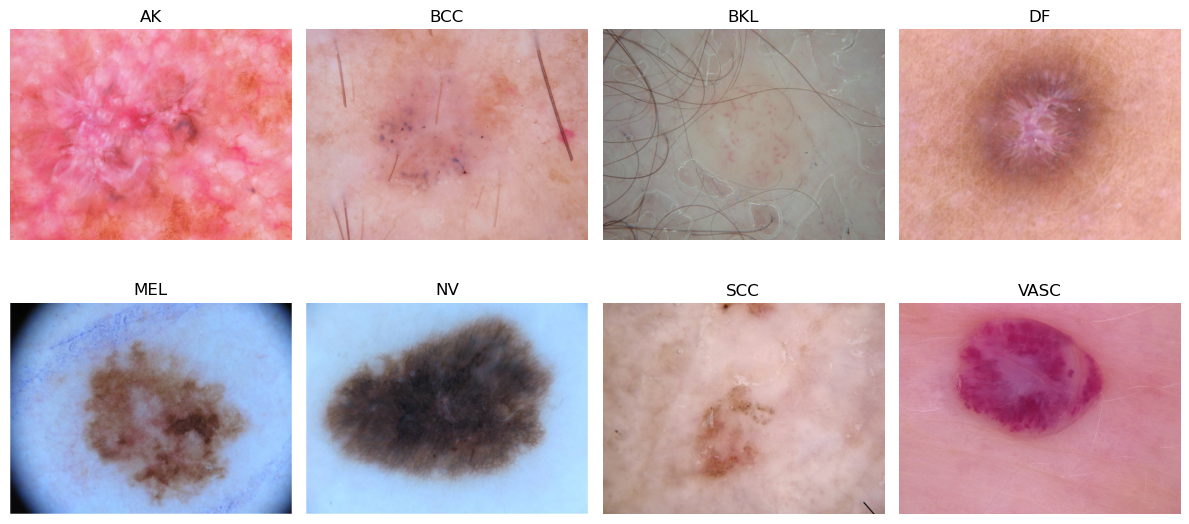

In [36]:
# get one image from each class
labels, image_paths = data.groupby('label').first()["name"].keys().tolist(), data.groupby('label').first()["name"].values.tolist()

def show_image(image_path, label):
    img = Image.open(image_path)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.figure(figsize=(12, 6))

for i, (path, label) in enumerate(zip(image_paths, labels)):
    show_image(path, label)
plt.tight_layout()
plt.show()



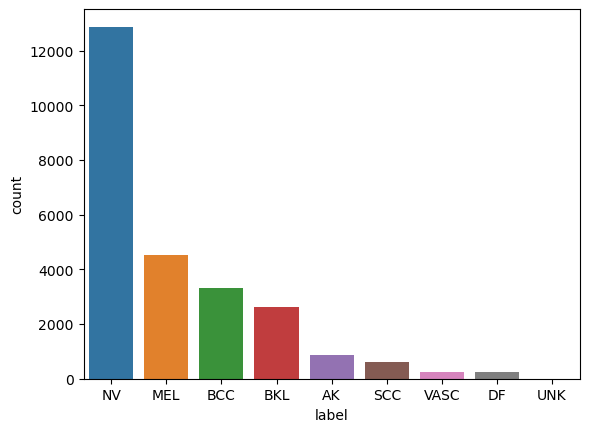

In [4]:
ax = sns.countplot(x="label", data=get_isic_df(), order=['NV', 'MEL', 'BCC', 'BKL', 'AK', 'SCC', 'VASC', 'DF','UNK'])

In [9]:
data['label'].unique()
for c in data['label'].unique():
    print(c, len(data[data['label'] == c]))

NV 12875
MEL 4522
BKL 2624
DF 239
SCC 628
BCC 3323
VASC 253
AK 867


In [10]:
data['label'].value_counts()
total_images = data.shape[0]

weights_loss = []

for c in data['label'].unique():
    samples = data['label'].value_counts()[c]
    weights_loss.append(1 / (samples / total_images))


normalized_weights = [x / sum(weights_loss) for x in weights_loss]
normalized_weights

[0.00654709040812095,
 0.018640820213303235,
 0.03212415739502943,
 0.3526936778433357,
 0.13422577866967714,
 0.025366773699836663,
 0.33317703163856616,
 0.09722467013213061]

In [6]:
from IPython.display import Image
import numpy as np
from PIL import Image

In [7]:
data["images"] = data["name"].apply(lambda x: np.array(Image.open(x)))

In [8]:
image_path = data.head(10).iloc[2]['name']
#Image(image_path)
# Load the image using Pillow
image_pil = Image.open(image_path)

# Convert the image to a NumPy array
image_np = np.array(image_pil)

#mean = np.mean(images, axis=(0, 1, 2))
#std = np.std(images, axis=(0, 1, 2))

In [22]:
#data["images"].to_numpy()# .mean(axis=(0, 1, 2))

data["images"].apply(lambda x: x.shape).value_counts()


(1024, 1024, 3)    12414
(450, 600, 3)      10015
(680, 1024, 3)      1121
(768, 1024, 3)       774
(682, 1024, 3)       173
                   ...  
(723, 959, 3)          1
(672, 964, 3)          1
(723, 957, 3)          1
(640, 957, 3)          1
(676, 962, 3)          1
Name: images, Length: 101, dtype: int64

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import pandas as pd
from PIL import Image

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = Image.open(self.dataframe.iloc[idx, 0])
        label = self.dataframe.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_isic_loaders():
    # Load the dataframe
    df = get_isic_df()

    # Split the data
    train_df, val_test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
    test_df, val_df = train_test_split(val_test_df, test_size=0.5, random_state=42, stratify=val_test_df['label'])

    # Define the transformations
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        #transforms.Normalize(mean=[0.6679, 0.5299, 0.5245], std=[0.1332, 0.1475, 0.1588]),
    ])

    # Create the DataLoaders
    train_loader = DataLoader(ISICDataset(train_df, transform=transform), batch_size=64, shuffle=True)
    val_loader = DataLoader(ISICDataset(val_df, transform=transform), batch_size=64, shuffle=False)
    test_loader = DataLoader(ISICDataset(test_df, transform=transform), batch_size=64, shuffle=False)

    return train_loader, val_loader, test_loader


In [25]:
import numpy as np

def compute_img_stats(loader):
    mean = 0.
    std = 0.
    nb_samples = 0.
    
    for data, _ in loader:
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        nb_samples += batch_samples

    mean /= nb_samples
    std /= nb_samples

    return mean, std

def get_stats(df):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
    loader = DataLoader(ISICDataset(df, transform=transform), batch_size=1024, shuffle=False)
    return compute_img_stats(loader)

# Load the dataframe
df = get_isic_df()

# Compute the statistics
mean, std = get_stats(df)

print('Mean:', mean)
print('Std:', std)

# Mean: tensor([0.6679, 0.5299, 0.5245])
# Std: tensor([0.1332, 0.1475, 0.1588])

Mean: tensor([0.6679, 0.5299, 0.5245])
Std: tensor([0.1332, 0.1475, 0.1588])
